In [17]:
from pathlib import Path
import pickle
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
FACED_ROOT = Path("/projects/EEG-foundation-model/datalake/raw/faced/Processed_data")
FACED_FILE_PATH = FACED_ROOT / "sub062.pkl"

In [19]:
FACED_CHANNEL_LIST = [
    "FP1", "FP2", "FZ", "F3", "F4", "F7", "F8", "FC1", "FC2", "FC5", "FC6",
    "CZ", "C3", "C4", "T7", "T8", "CP1", "CP2", "CP5", "CP6", "PZ", "P3", "P4",
    "P7", "P8", "PO3", "PO4", "OZ", "O1", "O2"
]

FACED_STAGE_MAP = {
    "1": 0, "2": 0, "3": 0,
    "4": 1, "5": 1, "6": 1,
    "7": 2, "8": 2, "9": 2,
    "10": 3, "11": 3, "12": 3,
    "13": 4, "14": 4, "15": 4, "16": 4,
    "17": 5, "18": 5, "19": 5,
    "20": 6, "21": 6, "22": 6,
    "23": 7, "24": 7, "25": 7,
    "26": 8, "27": 8, "28": 8,
}

In [20]:
files = sorted(FACED_ROOT.rglob("sub*.pkl"))

print(f"FACED root: {FACED_ROOT}")
print(f"Number of pkl files: {len(files)}")

files[:5], files[-5:]

FACED root: /projects/EEG-foundation-model/datalake/raw/faced/Processed_data
Number of pkl files: 123


([PosixPath('/projects/EEG-foundation-model/datalake/raw/faced/Processed_data/sub000.pkl'),
  PosixPath('/projects/EEG-foundation-model/datalake/raw/faced/Processed_data/sub001.pkl'),
  PosixPath('/projects/EEG-foundation-model/datalake/raw/faced/Processed_data/sub002.pkl'),
  PosixPath('/projects/EEG-foundation-model/datalake/raw/faced/Processed_data/sub003.pkl'),
  PosixPath('/projects/EEG-foundation-model/datalake/raw/faced/Processed_data/sub004.pkl')],
 [PosixPath('/projects/EEG-foundation-model/datalake/raw/faced/Processed_data/sub118.pkl'),
  PosixPath('/projects/EEG-foundation-model/datalake/raw/faced/Processed_data/sub119.pkl'),
  PosixPath('/projects/EEG-foundation-model/datalake/raw/faced/Processed_data/sub120.pkl'),
  PosixPath('/projects/EEG-foundation-model/datalake/raw/faced/Processed_data/sub121.pkl'),
  PosixPath('/projects/EEG-foundation-model/datalake/raw/faced/Processed_data/sub122.pkl')])

In [21]:
subject_ids = [f.stem for f in files]
unique_subjects = sorted(set(subject_ids))

print(f"Number of subjects: {len(unique_subjects)}")
print(f"First subjects: {unique_subjects[:10]}")
print(f"Last subjects: {unique_subjects[-10:]}")

Number of subjects: 123
First subjects: ['sub000', 'sub001', 'sub002', 'sub003', 'sub004', 'sub005', 'sub006', 'sub007', 'sub008', 'sub009']
Last subjects: ['sub113', 'sub114', 'sub115', 'sub116', 'sub117', 'sub118', 'sub119', 'sub120', 'sub121', 'sub122']


In [22]:
shape_counter = Counter()
dtype_counter = Counter()
bad_files = []

for f in files:
    try:
        with open(f, "rb") as fp:
            data = pickle.load(fp)

        shape_counter[getattr(data, "shape", None)] += 1
        dtype_counter[str(getattr(data, "dtype", None))] += 1

    except Exception as e:
        bad_files.append((f, repr(e)))

print("Shapes:")
for shape, count in shape_counter.items():
    print(f"{shape}: {count}")

print("\nDtypes:")
for dtype, count in dtype_counter.items():
    print(f"{dtype}: {count}")

print(f"\nBad files: {len(bad_files)}")
bad_files[:5]

Shapes:
(28, 32, 7500): 123

Dtypes:
float64: 123

Bad files: 0


[]

In [23]:
rows = []

for f in files:
    try:
        with open(f, "rb") as fp:
            data = pickle.load(fp)

        rows.append({
            "file": str(f),
            "subject": f.stem,
            "type": type(data).__name__,
            "shape": getattr(data, "shape", None),
            "ndim": getattr(data, "ndim", None),
            "dtype": str(getattr(data, "dtype", None)),
            "min": float(np.nanmin(data)) if isinstance(data, np.ndarray) else None,
            "max": float(np.nanmax(data)) if isinstance(data, np.ndarray) else None,
            "mean": float(np.nanmean(data)) if isinstance(data, np.ndarray) else None,
            "std": float(np.nanstd(data)) if isinstance(data, np.ndarray) else None,
        })

    except Exception as e:
        rows.append({
            "file": str(f),
            "subject": f.stem,
            "type": "ERROR",
            "shape": None,
            "ndim": None,
            "dtype": None,
            "min": None,
            "max": None,
            "mean": None,
            "std": None,
            "error": repr(e),
        })

df_files = pd.DataFrame(rows)
df_files.head()

,file,subject,type,shape,ndim,dtype,min,max,mean,std
0,/projects/EEG-foundation-model/datalake/raw/fa...,sub000,ndarray,"(28, 32, 7500)",3,float64,-637.058347,904.226040,-4.466269e-18,13.922669
1,/projects/EEG-foundation-model/datalake/raw/fa...,sub001,ndarray,"(28, 32, 7500)",3,float64,-323.666575,419.725915,-8.391171e-18,11.635581
2,/projects/EEG-foundation-model/datalake/raw/fa...,sub002,ndarray,"(28, 32, 7500)",3,float64,-219.142806,217.929426,2.097793e-18,11.081265
3,/projects/EEG-foundation-model/datalake/raw/fa...,sub003,ndarray,"(28, 32, 7500)",3,float64,-10901.713187,9220.116934,-1.272210e-17,367.690633
4,/projects/EEG-foundation-model/datalake/raw/fa...,sub004,ndarray,"(28, 32, 7500)",3,float64,-87885.237594,85297.464613,1.037392e-16,527.044575


In [24]:
df_files.groupby(["shape", "ndim", "dtype"]).size().reset_index(name="count")

,shape,ndim,dtype,count
0,"(28, 32, 7500)",3,float64,123


In [25]:
FACED_FILE_PATH = Path(FACED_FILE_PATH)

with open(FACED_FILE_PATH, "rb") as f:
    data = pickle.load(f)

print(f"File: {FACED_FILE_PATH}")
print(f"Type: {type(data)}")
print(f"Shape: {getattr(data, 'shape', None)}")
print(f"Dtype: {getattr(data, 'dtype', None)}")

if isinstance(data, np.ndarray):
    print(f"Min: {np.nanmin(data):.4f}")
    print(f"Max: {np.nanmax(data):.4f}")
    print(f"Mean: {np.nanmean(data):.4f}")
    print(f"Std: {np.nanstd(data):.4f}")

File: /projects/EEG-foundation-model/datalake/raw/faced/Processed_data/sub062.pkl
Type: <class 'numpy.ndarray'>
Shape: (28, 32, 7500)
Dtype: float64
Min: -183.2673
Max: 136.8740
Mean: 0.0000
Std: 6.9095


In [26]:
def describe_faced_array(data):
    if not isinstance(data, np.ndarray):
        return "Not a numpy array"

    if data.ndim == 3:
        n_trials, n_channels, n_samples = data.shape
        return {
            "format": "(trials, channels, samples)",
            "n_trials": n_trials,
            "n_channels": n_channels,
            "n_samples": n_samples,
            "expected_channels_match": n_channels == len(FACED_CHANNEL_LIST),
        }

    if data.ndim == 4:
        n_trials, a, b, c = data.shape
        return {
            "format": "4D array, likely (trials, channels, segments, features) or similar",
            "n_trials": n_trials,
            "dim_1": a,
            "dim_2": b,
            "dim_3": c,
            "expected_channels_match_dim1": a == len(FACED_CHANNEL_LIST),
        }

    return {
        "format": f"Unexpected ndim={data.ndim}",
        "shape": data.shape,
    }

describe_faced_array(data)

{'format': '(trials, channels, samples)',
 'n_trials': 28,
 'n_channels': 32,
 'n_samples': 7500,
 'expected_channels_match': False}

In [27]:
def simulate_load_data_current(file_path):
    with open(file_path, "rb") as f:
        data = pickle.load(f)
        data = data[:, :30, :]

    if not isinstance(data, np.ndarray) or data.ndim != 3:
        raise ValueError(
            f"Unexpected FACED pkl content: type={type(data)}, shape={getattr(data, 'shape', None)}"
        )

    n_trials, n_channels, n_samples = data.shape

    if len(FACED_CHANNEL_LIST) != n_channels:
        raise ValueError(
            f"FACED_channels mismatch: {len(FACED_CHANNEL_LIST)} vs {n_channels}"
        )

    x = np.concatenate([data[i] for i in range(n_trials)], axis=1).astype(np.float64, copy=False)
    return x

try:
    x_concat = simulate_load_data_current(FACED_FILE_PATH)
    print(f"Concatenated x shape: {x_concat.shape}")
except Exception as e:
    print(type(e).__name__, e)

Concatenated x shape: (30, 210000)


In [28]:
trial_labels = [FACED_STAGE_MAP[str(i + 1)] for i in range(28)]
label_distribution = Counter(trial_labels)

print("Trial labels:")
print(trial_labels)

print("\nLabel distribution:")
print(dict(label_distribution))

Trial labels:
[0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 6, 6, 6, 7, 7, 7, 8, 8, 8]

Label distribution:
{0: 3, 1: 3, 2: 3, 3: 3, 4: 4, 5: 3, 6: 3, 7: 3, 8: 3}


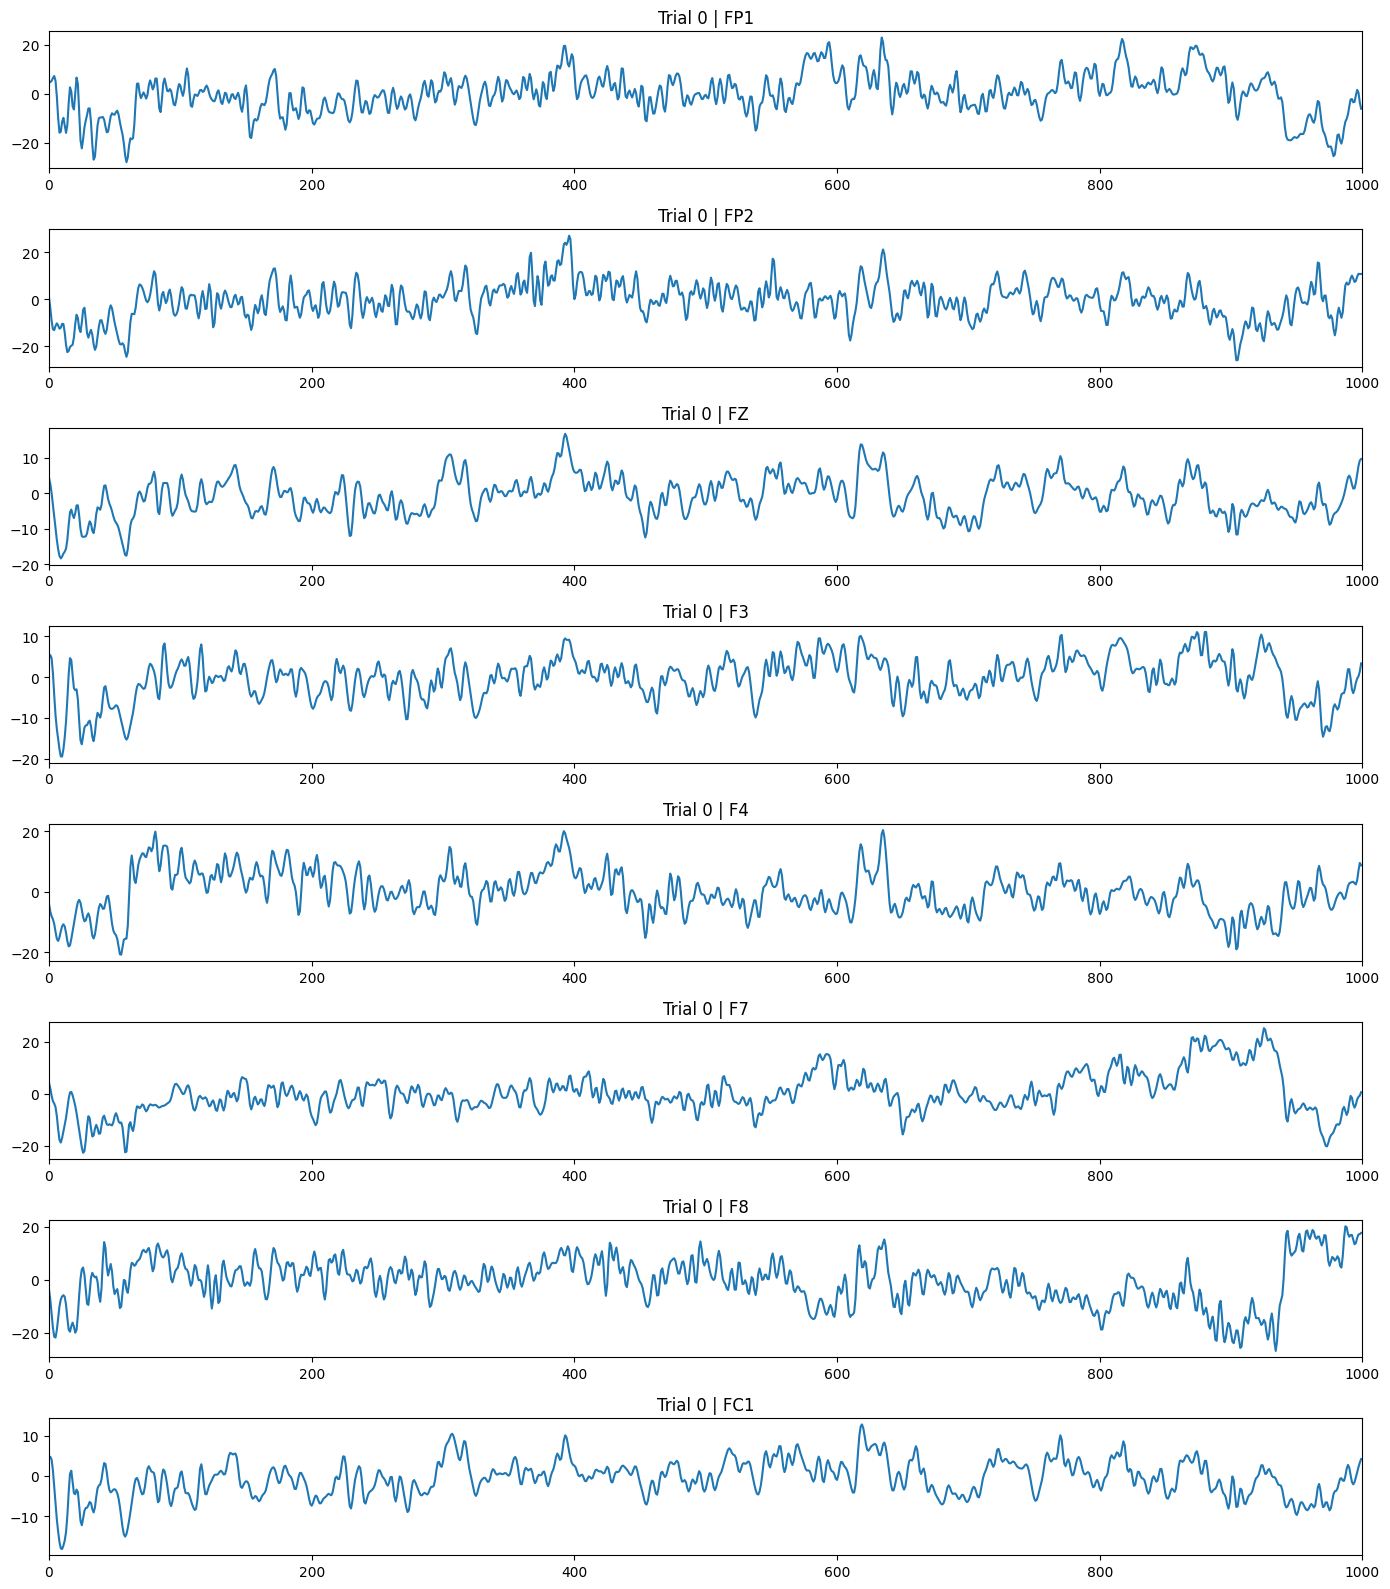

In [29]:
def plot_trial_3d(data, trial_idx=0, n_channels=8, t_start=0, t_len=1000):
    if data.ndim != 3:
        raise ValueError(f"Expected 3D data, got shape={data.shape}")

    n_trials, n_ch, n_samples = data.shape
    trial_idx = min(trial_idx, n_trials - 1)
    ch_k = min(n_channels, n_ch)

    s = max(0, t_start)
    e = min(n_samples, s + t_len)

    plt.figure(figsize=(14, 2 * ch_k))

    for i in range(ch_k):
        ax = plt.subplot(ch_k, 1, i + 1)
        ax.plot(data[trial_idx, i, s:e])
        name = FACED_CHANNEL_LIST[i] if i < len(FACED_CHANNEL_LIST) else f"Ch{i}"
        ax.set_title(f"Trial {trial_idx} | {name}")
        ax.set_xlim(0, e - s)

    plt.tight_layout()
    plt.show()

if isinstance(data, np.ndarray) and data.ndim == 3:
    plot_trial_3d(data, trial_idx=0, n_channels=8, t_start=0, t_len=1000)
else:
    print(f"Skipping plot: data shape is {getattr(data, 'shape', None)}")

In [30]:
def plot_trial_4d(data, trial_idx=0, channel_idx=0):
    if data.ndim != 4:
        raise ValueError(f"Expected 4D data, got shape={data.shape}")

    trial_idx = min(trial_idx, data.shape[0] - 1)
    channel_idx = min(channel_idx, data.shape[1] - 1)

    arr = data[trial_idx, channel_idx]

    plt.figure(figsize=(8, 5))
    plt.imshow(arr, aspect="auto")
    plt.colorbar()
    plt.title(f"4D view | trial={trial_idx} | channel={channel_idx} | shape={arr.shape}")
    plt.xlabel("Feature dim")
    plt.ylabel("Segment dim")
    plt.tight_layout()
    plt.show()

if isinstance(data, np.ndarray) and data.ndim == 4:
    plot_trial_4d(data, trial_idx=0, channel_idx=0)
else:
    print(f"Skipping 4D plot: data shape is {getattr(data, 'shape', None)}")

Skipping 4D plot: data shape is (28, 32, 7500)


In [31]:
files_4d = df_files[df_files["ndim"] == 4]["file"].tolist()

print(f"Number of 4D files: {len(files_4d)}")
files_4d[:20]

Number of 4D files: 0


[]

In [32]:
FACED_ROOT = Path("/projects/EEG-foundation-model/datalake/raw/faced/Processed_data")


import pickle
from pathlib import Path
from collections import Counter

FACED_ROOT = Path("/projects/EEG-foundation-model/datalake/raw/faced/Processed_data")

files = sorted(FACED_ROOT.rglob("sub*.pkl"))

counter = Counter()
bad = []

for f in files:
    with open(f, "rb") as fp:
        data = pickle.load(fp)

    shape = getattr(data, "shape", None)
    ndim = getattr(data, "ndim", None)

    counter[(ndim, shape)] += 1

    if ndim != 3:
        bad.append((f, type(data), shape, ndim))

print(f"n_files = {len(files)}")
print(counter)

print("\nNon-3D files:")
for item in bad[:50]:
    print(item)

f = Path("/projects/EEG-foundation-model/datalake/raw/faced/Processed_data/sub061.pkl")

with open(f, "rb") as fp:
    data = pickle.load(fp)

print(type(data))
print(getattr(data, "shape", None))
print(getattr(data, "ndim", None))

n_files = 123
Counter({(3, (28, 32, 7500)): 123})

Non-3D files:
<class 'numpy.ndarray'>
(28, 32, 7500)
3
